In [1]:
import numpy as np
import random
import scipy.stats as ss
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
from tqdm import tqdm
from numba import njit

El Hamiltonia de la particula $i$ és el seu nivell d'energia
$\epsilon$

$$
H(p_i) = \epsilon_i
$$

## Requeriments

- Nivell 3 despoblat quan $T < T_c,\quad T_c \simeq 10\epsilon/k_B
  lnN$.
- $C_V \sim T^{-2}e^{-\beta\epsilon}$
- Altes temperatures $C_V \sim T^{-2}$
- Ocupació mitjana en funció de T (analitzar <<1, >>1)
- Com garantir situació d'equilibri???
- Fluctuacions energia en funció de N

In [2]:
# VAIABLES
N = 1000
steps = 100_000
eps = 1.0
E_LEVELS = np.array([0,eps,10*eps])
states = np.random.choice([i for i in range(len(E_LEVELS))],N)

Tc = 10 * eps / np.log(N) # Critical Temperature from Problem 35
T = Tc * 10
# T_sim = Tc * 0.4  # Setting T below Tc to see the Level 3 depletion

print("Critical temperature", Tc)

Critical temperature 1.4476482730108395


In [3]:
# Utils
def theoretical_occupation(T):
    beta = 1.0 / (T)
    weights = np.exp(-beta * E_LEVELS)
    Z = np.sum(weights)
    return weights / Z
def plot_energies(Temperatures,E_history,population_history):
    size = 5
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.scatter(Temperatures,E_history, color='blue',s=size)
    plt.ylim(0)
    plt.title("Evolució Energia total")
    plt.xlabel("Temperatura")
    plt.ylabel("Energia del sistema")

    plt.subplot(1, 2, 2)
    plt.scatter(Temperatures,population_history[:, 0], label="Nivell 1 (0)",s=size)
    plt.scatter(Temperatures,population_history[:, 1], label="Nivell 2 (ε)",s=size)
    plt.scatter(Temperatures,population_history[:, 2], label="Nivell 3 (10ε)",s=size)
    plt.title("Partícules per nivell")
    plt.xlabel("Temperatura")
    plt.ylabel("Nombre de partícules")
    plt.ylim(0)
    plt.legend()
    plt.tight_layout()

def logspace_values(start_val, end_val, num=50, **kwargs):
    start_exp = np.log10(start_val)
    end_exp = np.log10(end_val)
    
    return np.logspace(start_exp, end_exp, num, **kwargs)

In [4]:
# Metropolis simulations (numba, no numba)
def run_metropolis_simulation(initial_state, E_levels, T, steps):
    """
    N: Number of particles
    T: Temperature
    epsilon: Energy scale constant
    steps: Number of Monte Carlo steps
    """
    kb = 1  # Boltzmann constant simplified
    beta = 1.0 / (kb * T) if T > 0 else float('inf')

    states = initial_state.copy()
    energy_levels = E_levels.copy()
    N = len(states)
    
    # Defined Energy Levels: E1=0, E2=eps, E3=10*eps
    
    energy_history = []
    population_history = np.zeros((steps, len(energy_levels)))

    for i in range(steps):
        # Pick a random particle
        idx = np.random.randint(0, N)
        current_state = states[idx]
        
        # Propose a new state (any of the 3 levels)
        proposed_state = np.random.choice([i for i in range(len(energy_levels))])
        
        # Calculate Energy Difference: dE = E_new - E_old
        dE = energy_levels[proposed_state] - energy_levels[current_state]
        dE = energy_levels[proposed_state] - energy_levels[current_state]
        
        # --- Metropolis Rule ---
        if dE <= 0:
            # If the new state is lower energy, always accept (Thermodynamically favored)
            states[idx] = proposed_state
        else:
            # If higher energy, accept with a specific probability
            acceptance_prob = np.exp(-beta * dE)
            if np.random.rand() < acceptance_prob:
                states[idx] = proposed_state
        
        # Data Logging
        total_energy = np.sum(energy_levels[states])
        energy_history.append(total_energy)
        for j in range(len(energy_levels)):
            population_history[i, j] = np.sum(states == j)

    return energy_history, population_history, states

@njit
def run_metropolis_numba(states, energy_levels,T,steps):
    # Physics Constants
    kb = 1.0
    beta = 1.0 / (kb * T) if T > 0 else np.inf
    energy_levels = energy_levels.copy()
    N = len(states)
    states = states.copy()
    
    # Initialize states (1/3 probability for each)
    # Note: Numba likes explicit loops or specific numpy calls
    
    # Pre-allocate arrays for results
    energy_history = np.empty(steps)
    population_history = np.empty((steps, 3))
    
    # Calculate initial total energy
    current_total_energy = 0.0
    for i in range(N):
        current_total_energy += energy_levels[states[i]]
    
    # Core Simulation Loop
    for i in range(steps):
        # Pick a random particle and a proposed new state
        idx = np.random.randint(0, N)
        current_state = states[idx]
        proposed_state = np.random.randint(0, 3)
        
        dE = energy_levels[proposed_state] - energy_levels[current_state]
        
        # Metropolis Rule
        if dE <= 0 or np.random.random() < np.exp(-beta * dE):
            # Accept change
            current_total_energy += dE
            states[idx] = proposed_state
            
        # Logging (This part can be slow, reduce frequency if needed)
        energy_history[i] = current_total_energy
        
        # Count populations efficiently
        p1, p2, p3 = 0, 0, 0
        for s in range(N):
            if states[s] == 0: p1 += 1
            elif states[s] == 1: p2 += 1
            else: p3 += 1
        population_history[i, 0] = p1
        population_history[i, 1] = p2
        population_history[i, 2] = p3

    return energy_history, population_history, states

In [5]:
E_history, population_history,new_states = run_metropolis_simulation(states,E_LEVELS,T,steps)

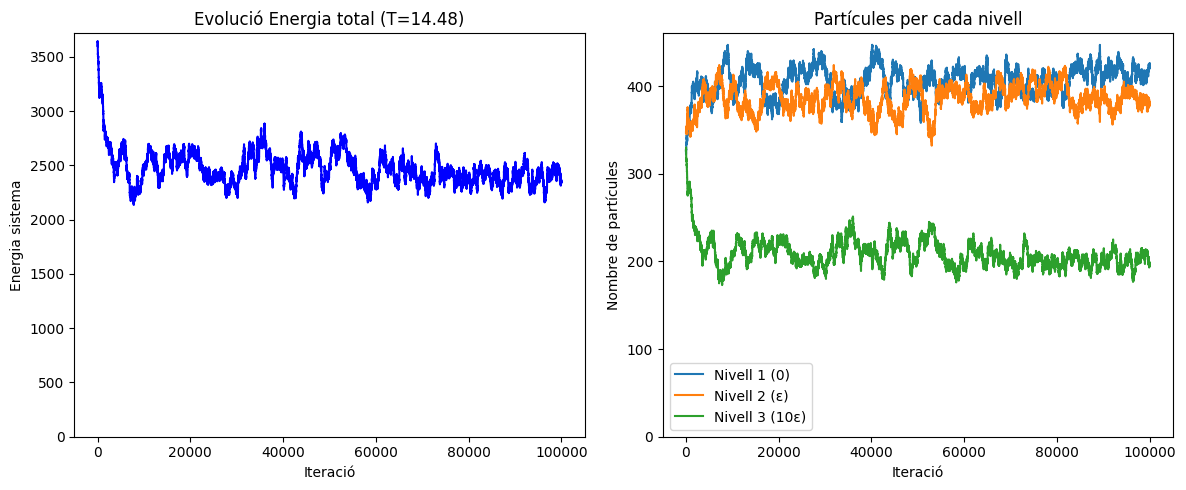

In [6]:
# Evolució en T (arbitraria)

# Visualization
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(E_history, color='blue')
plt.ylim(0)
plt.title(f"Evolució Energia total (T={T:.2f})")
plt.xlabel("Iteració")
plt.ylabel("Energia sistema")

plt.subplot(1, 2, 2)
plt.plot(population_history[:, 0], label="Nivell 1 (0)")
plt.plot(population_history[:, 1], label="Nivell 2 (ε)")
plt.plot(population_history[:, 2], label="Nivell 3 (10ε)")
plt.title("Partícules per cada nivell")
plt.xlabel("Iteració")
plt.ylabel("Nombre de partícules")
plt.ylim(0)
plt.legend()
plt.tight_layout()
plt.savefig(f"imatges/EvoT15{eps=:.2f}.png")
plt.show()

In [7]:
# Simula moltes temperatures
T_sample = logspace_values(1e-2, 100,1000)
all_E2 = []
all_pop2 = []
for temp in tqdm(T_sample):
    states = np.random.choice([i for i in range(len(E_LEVELS))],N)
    E_history, population_history,new_states = run_metropolis_numba(states,E_LEVELS,temp,steps)
    all_E2.append(E_history)
    all_pop2.append(population_history)
all_E2 = np.array(all_E2)
all_pop2 = np.array(all_pop2)

100%|██████████| 1000/1000 [01:11<00:00, 13.93it/s]


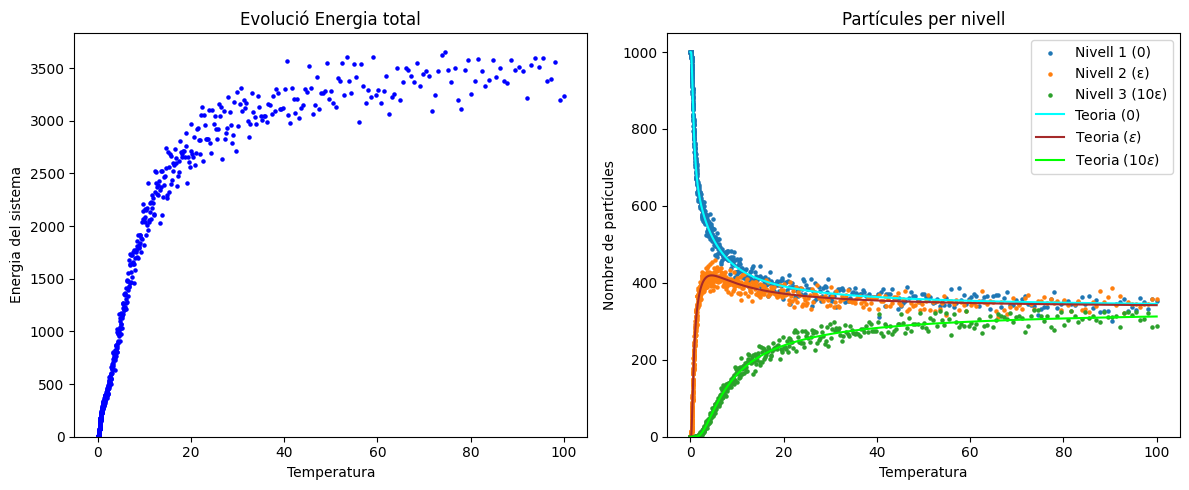

In [8]:
plot_energies(T_sample,all_E2[:,-1],all_pop2[:,-1])
theory = np.array([theoretical_occupation(T) for T in T_sample])
plt.subplot(1, 2, 2)
colors = ["cyan","brown","lime"]
energies = ["0",r"$\epsilon$",r"10$\epsilon$"]
for i in range(len(E_LEVELS)):
    plt.plot(T_sample,theory[:,i]*1000,c=colors[i],label=f"Teoria ({energies[i]})")
    plt.legend()
plt.savefig(f"imatges/Tsample{eps=:.2f}.png")

In [9]:
# Per quina temperatura Nivell 3 despoblat
pop_tot = all_pop2[:,-1]
pop3 = pop_tot[:,2]
indices = np.where(pop3 == 0)[0]
print(indices[-30:])
T0s = T_sample[indices]
print(T0s[-30:])
zero_indices = np.where(pop3 == 0)[0]
nonzero_indices = np.where(pop3 != 0)[0]

# Busquem els punts on el nivell 3 està despoblat
last_zero = zero_indices[-1]

first_nonzero = nonzero_indices[0]

start_idx = min(last_zero, first_nonzero)
end_idx = max(last_zero, first_nonzero)

# Fem la mitjana per trobar la temperatura crítica
target_slice = T_sample[start_idx : end_idx + 1]
average_val = np.mean(target_slice)

print(f"Index of last 0: {last_zero}")
print(f"Index of first non-zero: {first_nonzero}")
print("TEMPERATURA CRÍTICA EXPERIMENTAL:",average_val)
print("TEMPERATURA CRÍTICA TEÒRICA:     ",Tc)
print("Diferència",Tc-average_val)

[515 516 517 518 519 520 522 523 524 525 526 527 530 531 533 534 535 536
 537 538 539 540 541 542 545 546 548 550 560 575]
[1.1536181  1.16430313 1.17508713 1.18597101 1.1969557  1.20804213
 1.230524   1.24192135 1.25342427 1.26503372 1.2767507  1.28857621
 1.32471399 1.33698374 1.36186524 1.37447909 1.38720978 1.40005838
 1.41302599 1.42611371 1.43932264 1.45265393 1.46610868 1.47968806
 1.52118552 1.53527503 1.56384676 1.59295021 1.74679622 2.00586778]
Index of last 0: 575
Index of first non-zero: 507
TEMPERATURA CRÍTICA EXPERIMENTAL: 1.4909501848821818
TEMPERATURA CRÍTICA TEÒRICA:      1.4476482730108395
Diferència -0.04330191187134225


Al calcular $C_V$ hem de veure que per $T>>1$, $C_V \sim T^{-2}$

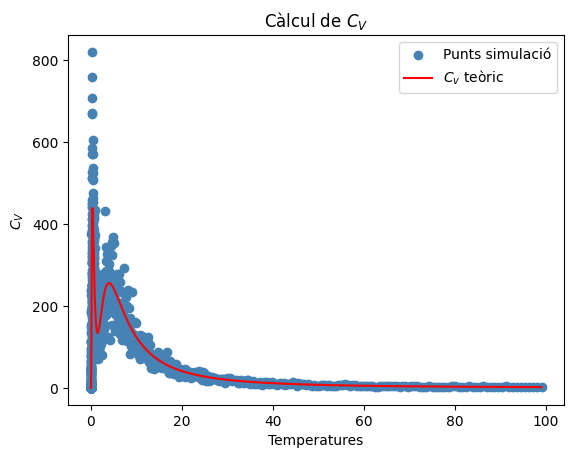

In [10]:
# Calcul C_v
aprox_min = -1
all_E2 = np.array(all_E2)
all_pop2 = np.array(all_pop2)
E_var = np.var(all_E2[:,all_E2.shape[1]//2:],axis=1)
C_v = E_var/(T_sample**2)
plt.scatter(T_sample[:aprox_min],C_v[:aprox_min],c="steelblue",label="Punts simulació")
beta_vals = 1.0 / T_sample
z = 1 + np.exp(-beta_vals * eps) + np.exp(-10 * beta_vals * eps)
avg_e = (eps * np.exp(-beta_vals * eps) + 10 * eps * np.exp(-10 * beta_vals * eps)) / z
avg_e2 = (eps**2 * np.exp(-beta_vals * eps) + 100 * eps**2 * np.exp(-10 * beta_vals * eps)) / z
theory_cv = N * (avg_e2 - avg_e**2) / (T_sample**2)
plt.plot(T_sample[:aprox_min], theory_cv[:aprox_min], 'r-', label='$C_v$ teòric')
plt.xlabel("Temperatures")
plt.ylabel("$C_V$")
plt.title("Càlcul de $C_V$")
plt.legend()
plt.savefig(f"imatges/CV_total{eps=:.2f}.png")

In [11]:
# Simula altes temperatures
T_sample = logspace_values(50, 4000,100)
all_E3 = []
all_pop3 = []
for temp in tqdm(T_sample):
    states = np.random.choice([i for i in range(len(E_LEVELS))],N)
    E_history, population_history,new_states = run_metropolis_numba(states,E_LEVELS,temp,steps)
    all_E3.append(E_history)
    all_pop3.append(population_history)
all_E3 = np.array(all_E3)
all_pop3 = np.array(all_pop3)
E_var = np.var(all_E3[:,all_E3.shape[1]//2:],axis=1)
C_v = E_var/(T_sample**2)

100%|██████████| 100/100 [00:13<00:00,  7.58it/s]


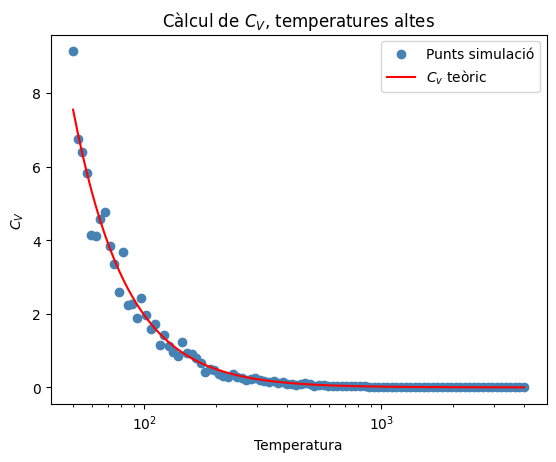

In [12]:
# Calcul C_v
aprox_min = 00
plt.scatter(T_sample[aprox_min:],C_v[aprox_min:],c="steelblue",label="Punts simulació")
beta_vals = 1.0 / T_sample
z = 1 + np.exp(-beta_vals * eps) + np.exp(-10 * beta_vals * eps)
avg_e = (eps * np.exp(-beta_vals * eps) + 10 * eps * np.exp(-10 * beta_vals * eps)) / z
avg_e2 = (eps**2 * np.exp(-beta_vals * eps) + 100 * eps**2 * np.exp(-10 * beta_vals * eps)) / z
theory_cv = (avg_e2 - avg_e**2) / (T_sample**2)
theory_cv = N * (avg_e2 - avg_e**2) / (T_sample**2)
plt.plot(T_sample[aprox_min:], theory_cv[aprox_min:], 'r-', label='$C_v$ teòric')
plt.xlabel("Temperatura")
plt.ylabel("$C_V$")
plt.title("Càlcul de $C_V$, temperatures altes")
plt.legend()
plt.xscale('log')
plt.savefig(f"imatges/CV{eps=:.2f}.png")

[ 1.92299059e+04 -1.18513919e-02]


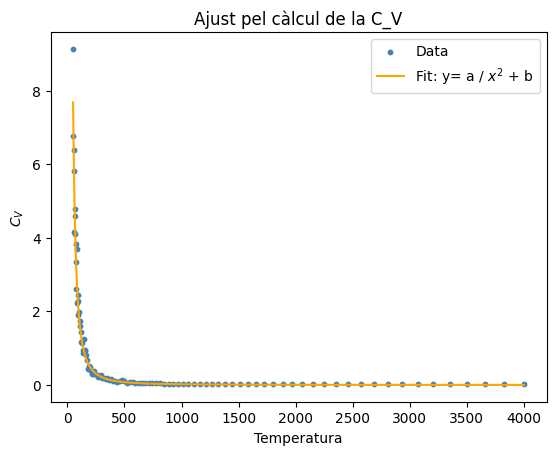

In [13]:
def inverse_square(x,a,b):
    return a/(x**2) + b

x_points = T_sample
y_points = C_v
theo_points = theory_cv
popt, pcov = curve_fit(inverse_square,x_points,y_points)

print(popt)
a = popt[0]
b = popt[1]
# 4. Visualization
# plt.figure(figsize=(12,5))
# plt.subplot(1,2,1)
plt.scatter(x_points, y_points, color='steelblue', label='Data',s=10)
plt.plot(x_points, inverse_square(x_points, popt[0],popt[1]), 
        #  label=f'Fit: y = {a:.3g} / x² + {b:.3g}',
         label=r"Fit: y= a / $x^2$ + b",
         c='orange')
plt.xlabel("Temperatura")
plt.ylabel("$C_V$")
plt.title("Ajust pel càlcul de la C_V")
plt.legend()
plt.savefig(f"imatges/CVfit{eps=:.2f}.png")
# plt.xscale('log')
# plt.yscale('log')
plt.show()

# plt.subplot(1,2,2)
# residuals = y_points - inverse_square(x_points, *popt)
# plt.scatter(x_points, residuals,s=10)
# plt.axhline(0, color='black', linestyle='--')
# plt.title("Residual Plot")
# plt.xscale('log')
# ss_res = np.sum((y_points - inverse_square(x_points, *popt))**2)
# ss_tot = np.sum((y_points - np.mean(y_points))**2)
# r_squared = 1 - (ss_res / ss_tot)
# print(f"R² Score: {r_squared}")
# plt.tight_layout()
# plt.show()

In [23]:
epsilon = 1.0     # Energy unit epsilon
kB = 1.0          # Boltzmann constant (reduced units)
T = 10.0           # Temperature
beta = 1.0 / (kB * T)

# Energy levels per molecule
energies = np.array([0.0, epsilon, 10.0 * epsilon])

# Simulation parameters
MC_steps = 50000  # Number of Monte Carlo steps per molecule
thermalization_steps = 10000
z = 1.0 + np.exp(-beta * epsilon) + np.exp(-10.0 * beta * epsilon)

# Single-particle average energy: <e> = sum(e_i * exp(-beta*e_i)) / z
mean_e_single = (0.0 + epsilon * np.exp(-beta * epsilon) + 10.0 * epsilon * np.exp(-10.0 * beta * epsilon)) / z

# Single-particle average squared energy: <e^2> = sum(e_i^2 * exp(-beta*e_i)) / z
mean_e2_single = (0.0 + (epsilon**2) * np.exp(-beta * epsilon) + (100.0 * epsilon**2) * np.exp(-10.0 * beta * epsilon)) / z

# Single-particle energy variance
var_e_single = mean_e2_single - (mean_e_single ** 2)

In [31]:
# Simulació moltes N
N_sample = np.array([10,20,50,100,200,500,1_000,2_000, 5_000,10_000,20_000,50_000])
all_E = []
all_pop = []
sim_mean_E = []
sim_var_E = []
sim_rel_fluc = []
for num in tqdm(N_sample):
    T = 20 * np.log(num)
    states = np.random.choice([i for i in range(len(E_LEVELS))],num)
    E_history, population_history,new_states = run_metropolis_numba(states,E_LEVELS,T,steps)
    all_E.append(E_history)
    all_pop.append(population_history)
    mean_E = np.mean(E_history)
    var_E = np.var(E_history)
    std_E = np.sqrt(var_E)
    
    sim_mean_E.append(mean_E)
    sim_var_E.append(var_E)
    sim_rel_fluc.append(std_E / mean_E)
all_E = np.array(all_E)
all_pop = np.array(all_pop)

  0%|          | 0/12 [00:00<?, ?it/s]

100%|██████████| 12/12 [00:25<00:00,  2.13s/it]


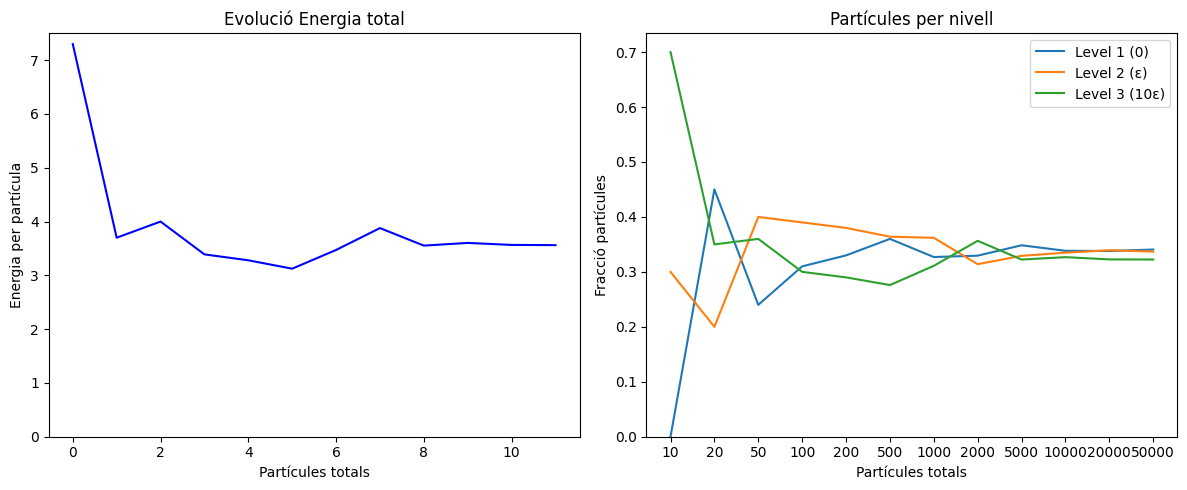

In [32]:
# Energia en funció de N (només 10 simulacions)
E_history = all_E[:,-1] / N_sample
# E_history = all_E[:,-1]
population_history = all_pop[:,-1] / N_sample[:, np.newaxis]
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(E_history, color='blue')
plt.ylim(0)
plt.title("Evolució Energia total")
plt.xlabel("Partícules totals")
plt.ylabel("Energia per partícula")

plt.subplot(1, 2, 2)
plt.plot(population_history[:, 0], label="Level 1 (0)")
plt.plot(population_history[:, 1], label="Level 2 (ε)")
plt.plot(population_history[:, 2], label="Level 3 (10ε)")
plt.xticks([i for i in range(len(N_sample))],N_sample)
plt.title("Partícules per nivell")
plt.xlabel("Partícules totals")
plt.ylabel("Fracció partícules")
plt.ylim(0)
plt.legend()
plt.tight_layout()
plt.savefig(f"imatges/CanviN{eps=:.2f}.png")
plt.show()

12


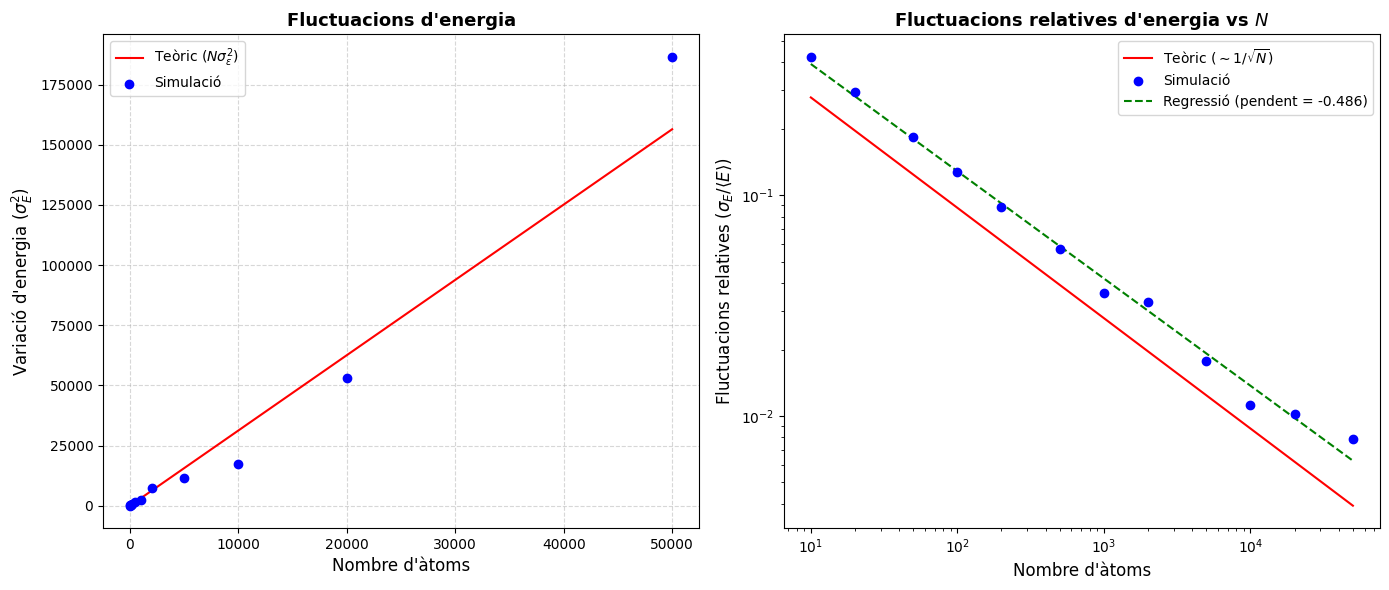

In [36]:

# Convert lists to arrays
sim_mean_E = np.array(sim_mean_E)
sim_var_E = np.array(sim_var_E)
sim_rel_fluc = np.array(sim_rel_fluc)

# Exact scaling curves for comparison
theory_mean_E = N_sample * mean_e_single
theory_var_E = N_sample * var_e_single * 0.25
theory_rel_fluc = np.sqrt(theory_var_E) / theory_mean_E

# ==========================================
# 4. PLOTTING THE RESULTS
# ==========================================
plt.figure(figsize=(14, 6))

# Subplot 1: Absolute Fluctuation (Variance) vs N
plt.subplot(1, 2, 1)
print(len(sim_var_E))
plt.plot(N_sample, theory_var_E, 'r-', label='Teòric ($N \\sigma_\\epsilon^2$)')
plt.scatter(N_sample, sim_var_E / np.log(N_sample), color='blue', zorder=5, label='Simulació')
plt.xlabel("Nombre d'àtoms", fontsize=12)
plt.ylabel("Variació d'energia ($\\sigma_E^2$)", fontsize=12)
plt.title("Fluctuacions d'energia", fontsize=13, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

# Subplot 2: Relative Fluctuation vs N (Log-Log)
plt.subplot(1, 2, 2)
plt.loglog(N_sample, theory_rel_fluc, 'r-', label='Teòric ($\\sim 1/\\sqrt{N}$)')
plt.scatter(N_sample, sim_rel_fluc, color='blue', zorder=5, label='Simulació')

# Fit a line to the simulated log-log data to find the power-law exponent
slope, intercept = np.polyfit(np.log(N_sample), np.log(sim_rel_fluc), 1)
plt.loglog(N_sample, np.exp(intercept) * (N_sample ** slope), 'g--', 
           label=f'Regressió (pendent = {slope:.3f})')

plt.xlabel("Nombre d'àtoms", fontsize=12)
plt.ylabel("Fluctuacions relatives ($\\sigma_E / \\langle E \\rangle$)", fontsize=12)
plt.title("Fluctuacions relatives d'energia vs $N$", fontsize=13, fontweight='bold')
plt.legend()

plt.tight_layout()
plt.show()